# CCGT NPV simulation

Run the CCGT electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_model import simulate_ccgt_npv

In [12]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_ccgt_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,ccgt,1000000.0,4650.0,215.053763,215053.763441,1273.398298,19.368496,5.770804,1.688980,...,94070000.0,4.165268e+06,5.770804e+06,1.041169e+08,2.687273e+07,-4.685570e+07,-7.740232e+08,25000000.0,-30.960929,-3.096093e-05
1,1,ccgt,1000000.0,4650.0,215.053763,215053.763441,1251.774386,20.792029,4.922929,1.671110,...,94070000.0,4.471404e+06,4.922929e+06,3.144206e+07,2.724285e+07,2.599076e+07,8.246745e+06,25000000.0,0.329870,3.298698e-07
2,2,ccgt,1000000.0,4650.0,215.053763,215053.763441,1188.132098,20.745656,5.524449,1.651450,...,94070000.0,4.461431e+06,5.524449e+06,2.681736e+07,2.706131e+07,3.020545e+07,6.692414e+07,25000000.0,2.676966,2.676966e-06
3,3,ccgt,1000000.0,4650.0,215.053763,215053.763441,1295.922142,20.711710,5.503047,1.701835,...,94070000.0,4.454131e+06,5.503047e+06,1.048430e+08,2.677152e+07,-4.750167e+07,-7.857626e+08,25000000.0,-31.430505,-3.143051e-05
4,4,ccgt,1000000.0,4650.0,215.053763,215053.763441,1089.902295,23.170713,5.821725,1.636901,...,94070000.0,4.982949e+06,5.821725e+06,8.380621e+07,2.694719e+07,-2.748807e+07,-5.278166e+08,25000000.0,-21.112664,-2.111266e-05


In [13]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-320.596632,-12.823865,-0.000013
std,252.415470,10.096619,0.000010
min,-1259.444350,-50.377774,-0.000050
5%,-776.160944,-31.046438,-0.000031
50%,-294.890754,-11.795630,-0.000012
95%,46.965594,1.878624,0.000002
max,209.113796,8.364552,0.000008


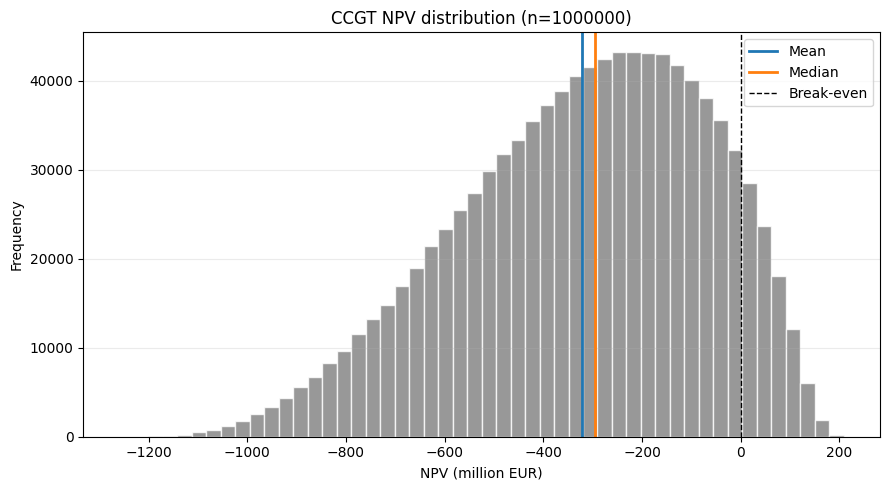

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


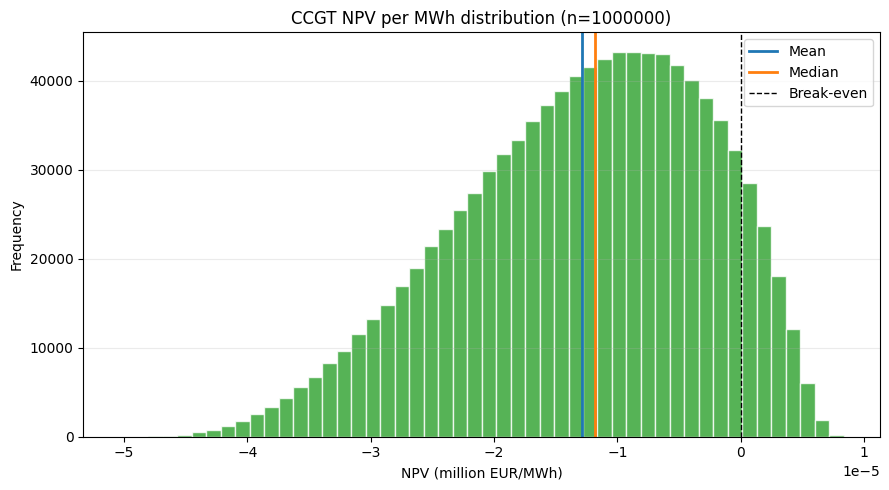

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [16]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         4.444740
annual_variable_opex_eur      5.166460
annual_fuel_cost_eur         65.367069
annual_emissions_cost_eur    26.960648
annual_net_cash_flow_eur     -7.868918
Name: Mean annual value, million EUR, dtype: float64